In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from datasets import load_dataset

ds = load_dataset("cfilt/iitb-english-hindi")

README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  190MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.7kB            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  500kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

In [3]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})


In [4]:
print(ds['train'][0])

{'translation': {'en': 'Give your application an accessibility workout', 'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}


In [10]:
for i in range(5):
  sample = ds['train'][i]['translation']
  print('English: ', sample['en'])
  print('Hindi: ', sample['hi'])
  print('-*'*30)

English:  Give your application an accessibility workout
Hindi:  अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
English:  Accerciser Accessibility Explorer
Hindi:  एक्सेर्साइसर पहुंचनीयता अन्वेषक
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
English:  The default plugin layout for the bottom panel
Hindi:  निचले पटल के लिए डिफोल्ट प्लग-इन खाका
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
English:  The default plugin layout for the top panel
Hindi:  ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
English:  A list of plugins that are disabled by default
Hindi:  उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से निष्क्रिय किया गया है
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*


In [11]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Why are we doing this?

Before writing preprocessing code, we need to understand the real data, including:

punctuation
capitalization
Hindi Unicode
empty sentences
unusually long sentences
formatting problems

In [12]:
#conver to dataframe
train_df = pd.DataFrame({
    'english': [
        x['en'] for x in ds['train']['translation']
    ],
    'hindi': [
        x['hi'] for x in ds['train']['translation']
    ]
})
print(train_df.head())
print(train_df.shape)

                                          english  \
0  Give your application an accessibility workout   
1               Accerciser Accessibility Explorer   
2  The default plugin layout for the bottom panel   
3     The default plugin layout for the top panel   
4  A list of plugins that are disabled by default   

                                               hindi  
0    अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें  
1                    एक्सेर्साइसर पहुंचनीयता अन्वेषक  
2              निचले पटल के लिए डिफोल्ट प्लग-इन खाका  
3               ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका  
4  उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...  
(1659083, 2)


In [13]:
#basic information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659083 entries, 0 to 1659082
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   english  1659083 non-null  object
 1   hindi    1659083 non-null  object
dtypes: object(2)
memory usage: 25.3+ MB


In [14]:
#cheching whether either language contains missing values
train_df.isnull().sum()

,0
english,0
hindi,0


In [15]:
print("English empty:", (train_df["english"].str.strip() == "").sum())
print("Hindi empty  :", (train_df["hindi"].str.strip() == "").sum())

English empty: 721
Hindi empty  : 6047


In [16]:
train_df = train_df[
    train_df['english'].fillna("").str.strip().ne("")&
    train_df['hindi'].fillna("").str.strip().ne("")
].copy()
train_df = train_df.reset_index(drop=True)

In [17]:
print("English empty:", train_df["english"].fillna("").str.strip().eq("").sum())
print("Hindi empty  :", train_df["hindi"].fillna("").str.strip().eq("").sum())

print("New shape:", train_df.shape)

English empty: 0
Hindi empty  : 0
New shape: (1652981, 2)


In [19]:
#duplicate analysis
'''
this inportant because duplicate sentence pairs dont provide additional
information to the model
'''

duplicates = train_df.duplicated(
    subset=['english', 'hindi']
).sum()

print('Duplicate pairs:', duplicates)

Duplicate pairs: 217707


In [20]:
english_duplicates = train_df['english'].duplicated().sum()
print('Repeated english sentences: ', english_duplicates)

Repeated english sentences:  563741


In [21]:
english_duplicates = train_df['hindi'].duplicated().sum()
print('Repeated english sentences: ', english_duplicates)

Repeated english sentences:  589944


In [22]:
print("Total rows:", len(train_df))
print("Unique English:", train_df["english"].nunique())
print("Unique Hindi:", train_df["hindi"].nunique())
print("Unique pairs:", train_df[["english", "hindi"]].drop_duplicates().shape[0])

Total rows: 1652981
Unique English: 1089240
Unique Hindi: 1063037
Unique pairs: 1435274


In [23]:
#remove exact duplicate english-hindi translation pairs
train_df = train_df.drop_duplicates(
    subset=['english', 'hindi']
).reset_index(drop=True)
print('New dataset size: ', len(train_df))

New dataset size:  1435274


In [24]:
print(
    "Duplicate pairs remaining:",
    train_df.duplicated(subset=["english", "hindi"]).sum()
)

Duplicate pairs remaining: 0


In [25]:
# Text cleaning

def clean_txt(text):
  text = str(text)
  #remove leading/trailing whitespace
  text = text.strip()
  #replace multiple spaces with one
  text = re.sub(r'\s+', " ", text)
  return text

In [26]:
train_df['english'] = train_df['english'].apply(clean_txt)
train_df['hindi'] = train_df['hindi'].apply(clean_txt)

In [27]:
train_df[['english', 'hindi']].head(10)

,english,hindi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...
5,Highlight duration,अवधि को हाइलाइट रकें
6,The duration of the highlight box when selecti...,पहुंचनीय आसंधि (नोड) को चुनते समय हाइलाइट बक्स...
7,Highlight border color,सीमांत (बोर्डर) के रंग को हाइलाइट करें
8,The color and opacity of the highlight border.,हाइलाइट किए गए सीमांत का रंग और अपारदर्शिता।
9,Highlight fill color,भराई के रंग को हाइलाइट करें


In [28]:
#chech whether cleaning created any empty sentences
print("English empty:", train_df["english"].eq("").sum())
print("Hindi empty  :", train_df["hindi"].eq("").sum())

English empty: 0
Hindi empty  : 0


In [29]:
# word length analysis
'''
before deciding our transformer sequence length, let's understand the data
'''

train_df['english_words'] = train_df['english'].str.split().str.len()
train_df['hindi_words'] = train_df['hindi'].str.split().str.len()

In [30]:
train_df[['english_words',
          'hindi_words'
          ]].describe()

,english_words,hindi_words
count,1.435274e+06,1.435274e+06
mean,1.410324e+01,1.524297e+01
std,1.562820e+01,1.702715e+01
min,1.000000e+00,1.000000e+00
25%,3.000000e+00,3.000000e+00
50%,1.000000e+01,1.100000e+01
75%,2.000000e+01,2.100000e+01
max,1.917000e+03,1.380000e+03


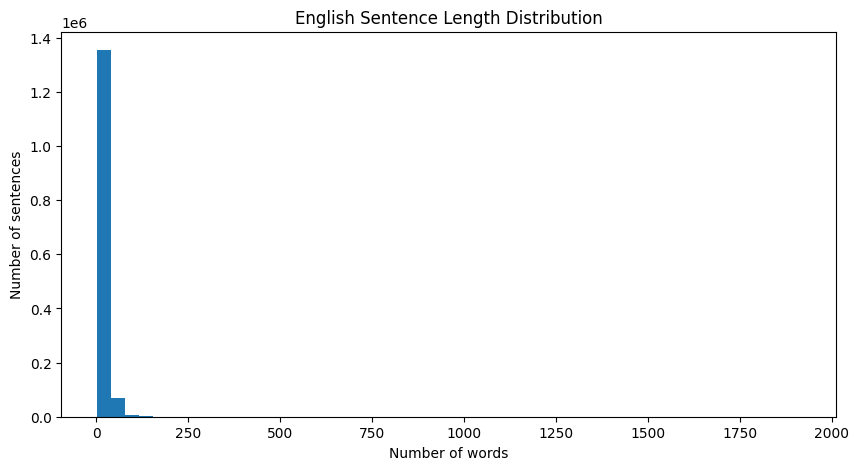

In [31]:
#visualize sentence lengths
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["english_words"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("English Sentence Length Distribution")

plt.show()

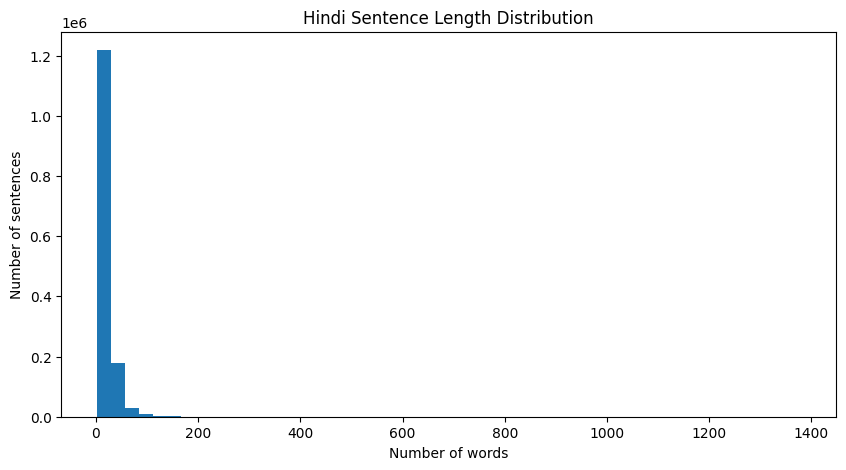

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["hindi_words"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("Hindi Sentence Length Distribution")

plt.show()

In [34]:
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]

print("English:")
print(np.percentile(train_df["english_words"], percentiles))

print("\nHindi:")
print(np.percentile(train_df["hindi_words"], percentiles))

English:
[ 10.  20.  32.  41.  71.  87. 133.]

Hindi:
[ 11.  21.  34.  46.  79.  97. 144.]


In [36]:
longest_english = train_df.sort_values(
    "english_words",
    ascending=False
).head(10)

for _, row in longest_english.iterrows():
    print("English:", row["english"])
    print("Words:", row["english_words"])
    print("Hindi:", row["hindi"])
    print("Words:", row["hindi_words"])
    print("-*" * 100)

English: Puranic 70 'Goti' system, a variety of serfdom 116 Govinda Chandra, his life story Guppa Sing, offerings to 24 Hadipa, Mayanabati becomes disciple of 46 Harishchandra, legend of 42 Hill Bhuiyan offer pig during Dusserah to local goddess 105 Hill Bondo, primitive tribe, their story of Creation 58 their myths 62, 64 - 6 6 Hill Saora 18 their myths, 18, 21, 26, 59, 80 their notions about the brahmin 18 Hindu castes in old days 17 Hindu pantheon 18, 60, 69, 82, 97 - 100 some local gods assimilated into 81 the trinity Brahma, Vishnu, Shiva 60, 70 Hindu Raja, powers of 30 Hinduism, its local cults imbibed by tribals 12 Hingulei, goddess 114 Hirakud Dam 14 Holi 101, 108 legend about 108 Humo songs of love 44 Indra 47 rains attributed to God 66 Inter - village organisation among Oraons, Mundas, Santhals 31 Intoxicants, their role in life of tribals 33 Jagannath, cult of 2 festival of Lord 97 Impact of Jainism on 2 in folk songs 38 myths about 70 Jagannath temple, architecture and scul

In [37]:
#Initial length filtering
max_words = 50
filtered_df = train_df[
    (train_df["english_words"] <= max_words) &
    (train_df["hindi_words"] <= max_words)
].copy()

In [38]:
print("Original:", len(train_df))
print("Filtered:", len(filtered_df))
print("Removed :", len(train_df) - len(filtered_df))

Original: 1435274
Filtered: 1374653
Removed : 60621


In [39]:
#look at filtered data
print(filtered_df.head(10))

                                             english  \
0     Give your application an accessibility workout   
1                  Accerciser Accessibility Explorer   
2     The default plugin layout for the bottom panel   
3        The default plugin layout for the top panel   
4     A list of plugins that are disabled by default   
5                                 Highlight duration   
6  The duration of the highlight box when selecti...   
7                             Highlight border color   
8     The color and opacity of the highlight border.   
9                               Highlight fill color   

                                               hindi  english_words  \
0    अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें              6   
1                    एक्सेर्साइसर पहुंचनीयता अन्वेषक              3   
2              निचले पटल के लिए डिफोल्ट प्लग-इन खाका              8   
3               ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका              8   
4  उन प्लग-इनों की सूची जिन्

In [40]:
#create final columns
processed_df = filtered_df[
    ["english", "hindi"]
].reset_index(drop=True)

In [41]:
print(processed_df.head())
print(processed_df.shape)

                                          english  \
0  Give your application an accessibility workout   
1               Accerciser Accessibility Explorer   
2  The default plugin layout for the bottom panel   
3     The default plugin layout for the top panel   
4  A list of plugins that are disabled by default   

                                               hindi  
0    अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें  
1                    एक्सेर्साइसर पहुंचनीयता अन्वेषक  
2              निचले पटल के लिए डिफोल्ट प्लग-इन खाका  
3               ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका  
4  उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...  
(1374653, 2)


In [42]:
#save proceesed training data
processed_df.to_parquet(
    'train_processed.parquet',
    index=False
)

In [44]:
#prepare validation
validation_df = pd.DataFrame({
    "english": [
        x["en"]
        for x in ds["validation"]["translation"]
    ],
    "hindi": [
        x["hi"]
        for x in ds["validation"]["translation"]
    ]
})

validation_df["english"] = validation_df["english"].apply(clean_txt)
validation_df["hindi"] = validation_df["hindi"].apply(clean_txt)

print(validation_df.shape)

(520, 2)


In [45]:
#prepare text
test_df = pd.DataFrame({
    "english": [
        x["en"]
        for x in ds["test"]["translation"]
    ],
    "hindi": [
        x["hi"]
        for x in ds["test"]["translation"]
    ]
})

test_df["english"] = test_df["english"].apply(clean_txt)
test_df["hindi"] = test_df["hindi"].apply(clean_txt)

print(test_df.shape)

(2507, 2)


In [46]:
import os

save_dir = "/content/drive/MyDrive/Translation Language Translator /processed"

os.makedirs(save_dir, exist_ok=True)

In [47]:
# Save train
processed_df.to_parquet(
    f"{save_dir}/train_processed.parquet",
    index=False
)

# Save validation
validation_df.to_parquet(
    f"{save_dir}/validation_processed.parquet",
    index=False
)

# Save test
test_df.to_parquet(
    f"{save_dir}/test_processed.parquet",
    index=False
)

# Verify
print("Saved files:")
print(os.listdir(save_dir))

Saved files:
['train_processed.parquet', 'validation_processed.parquet', 'test_processed.parquet']


**Dataset Preprocessing Summary**

In this notebook, the English–Hindi translation dataset was preprocessed to make it suitable for model training. The dataset was first converted from the Hugging Face DatasetDict format into Pandas DataFrames containing separate English and Hindi columns.

The dataset was checked for empty sentences, and rows containing empty English or Hindi text were removed. Exact duplicate English–Hindi sentence pairs were also identified and removed, while repeated sentences with different translations were retained.

Basic text cleaning was performed by removing unnecessary whitespace and leading/trailing spaces. Sentence lengths were then analyzed to identify unusually long and potentially noisy records.

The validation and test datasets were processed using the same basic cleaning steps. Finally, the processed train, validation, and test datasets were saved as Parquet files for use in the next stage of the project.